# Step 1 (V13): High-Precision XGBoost - Maximizing TP/FP Ratio

## 🎯 Objective:
Meningkatkan rasio **True Positives (TP)** terhadap **False Positives (FP)**. Kita ingin memperbesar 'Kotak Tua' dan memperkecil 'Kotak Muda' agar sinyal yang dikirim ke Markowitz jauh lebih berkualitas.

## ⚖️ Strategy: Probability Thresholding
Masalah pada model proaktif biasa (V10) adalah ia menebak 1 jika probabilitasnya > 0.50. Angka 0.51 dianggap sama kuatnya dengan 0.90.

**Di V13 ini, kita menggunakan standar yang lebih tinggi:**
1.  **Confidence Check**: AI hanya boleh memberikan sinyal 1 jika tingkat keyakinannya di atas **Threshold tertentu (misal 55% atau 60%)**.
2.  **Filter Noise**: Dengan menaikkan standar keyakinan, kita secara otomatis membuang sinyal-sinyal yang 'ragu-ragu' yang biasanya menjadi sumber False Positives (Kotak Muda).
3.  **Result**: Rasio TP/FP akan meningkat, membuat strategi investasi Anda jauh lebih aman.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, precision_score, accuracy_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ V13 Environment Ready (Precision Optimizer)")

✅ V13 Environment Ready (Precision Optimizer)


## 1. Feature Engineering (Same as V10)

In [2]:
data = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['RSI_14'] = calculate_rsi(market_return, 14)
features['Ret_Lag1'] = market_return.shift(1)
features['Vol_Shift'] = features['Vol_20'].pct_change()

features['Target'] = (market_return.rolling(window=5).mean().shift(-5) > 0).astype(int)
features = features.dropna()

X = features.drop('Target', axis=1)
y = features['Target']

X_train, y_train = X[X.index.year <= 2024], y[y.index.year <= 2024]
X_test, y_test = X[X.index.year == 2025], y[y.index.year == 2025]

print(f"📌 Data points for testing: {len(X_test)}")

📌 Data points for testing: 365


## 2. Training XGBoost

In [3]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
print("🚀 Base Model Trained.")

🚀 Base Model Trained.


## 3. Optimizing the Threshold (The Game Changer)
Kita akan mencari Threshold yang menghasilkan rasio TP:FP terbaik.

--- Threshold Comparison Table ---
 Threshold  TP  FP  Ratio_TP_FP  Precision
      0.50 136 123     1.105691   0.525097
      0.53 129 118     1.093220   0.522267
      0.54 127 114     1.114035   0.526971
      0.55 121 108     1.120370   0.528384
      0.56 120 104     1.153846   0.535714
      0.57 117 101     1.158416   0.536697
      0.58 114  99     1.151515   0.535211
      0.59 114  96     1.187500   0.542857
      0.60 108  94     1.148936   0.534653
      0.61 106  94     1.127660   0.530000


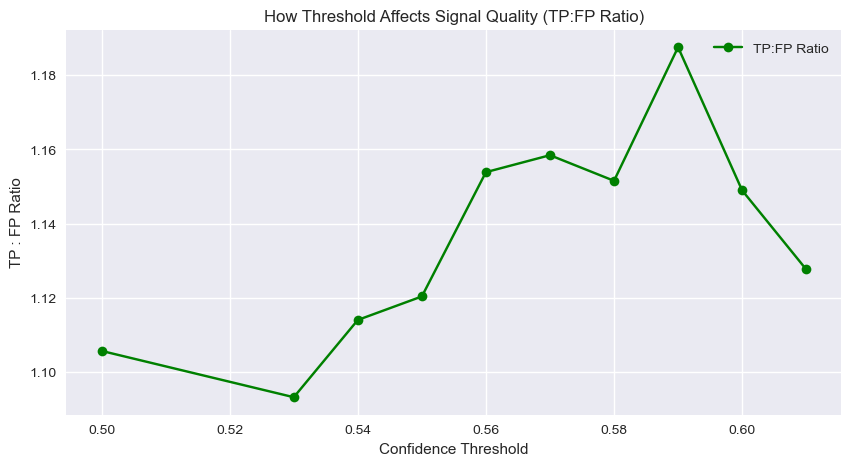

In [4]:
# Ambil probabilitas untuk kelas 1
probs = xgb_model.predict_proba(X_test)[:, 1]

def evaluate_threshold(threshold):
    custom_preds = (probs >= threshold).astype(int)
    cm = confusion_matrix(y_test, custom_preds)
    tp = cm[1,1]
    fp = cm[0,1]
    ratio = tp / fp if fp > 0 else tp
    precision = precision_score(y_test, custom_preds)
    return tp, fp, ratio, precision

results = []
for t in [0.5, 0.53, 0.54 , 0.55,  0.56, 0.57, 0.58 ,0.59, 0.6, 0.61]:
    tp, fp, ratio, prec = evaluate_threshold(t)
    results.append({'Threshold': t, 'TP': tp, 'FP': fp, 'Ratio_TP_FP': ratio, 'Precision': prec})

res_df = pd.DataFrame(results)
print("--- Threshold Comparison Table ---")
print(res_df.to_string(index=False))

# Visualizing the Trade-off
plt.figure(figsize=(10, 5))
plt.plot(res_df['Threshold'], res_df['Ratio_TP_FP'], marker='o', label='TP:FP Ratio', color='green')
plt.title("How Threshold Affects Signal Quality (TP:FP Ratio)")
plt.xlabel("Confidence Threshold")
plt.ylabel("TP : FP Ratio")
plt.legend()
plt.show()

## 4. Final Comparison Matrix (Threshold vs Normal)
Pilih threshold terbaik (misal 0.55 atau 0.57) untuk melihat perbedaannya secara visual.

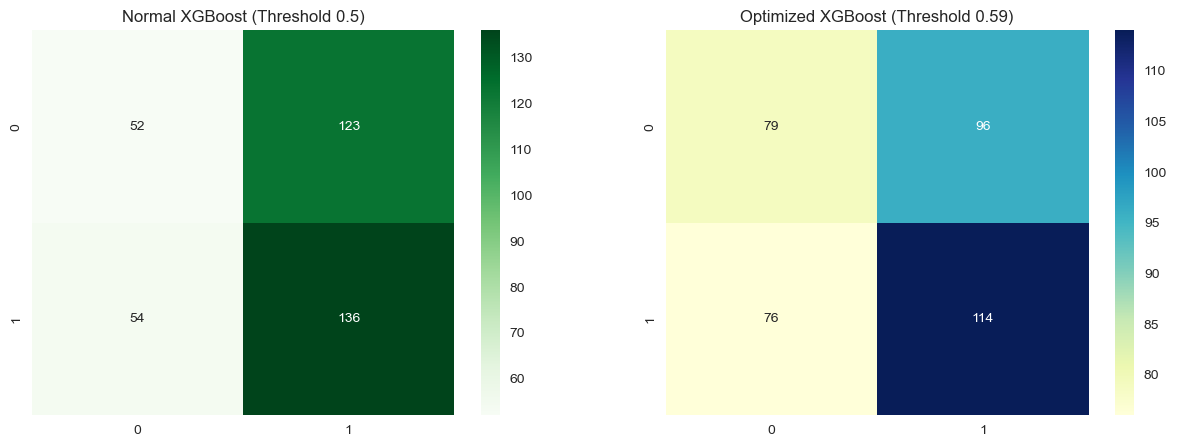

In [5]:
best_t = 0.59 # Anda bisa mengubah ini berdasarkan tabel di atas
final_preds = (probs >= best_t).astype(int)
cm_final = confusion_matrix(y_test, final_preds)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Normal (0.5)
normal_cm = confusion_matrix(y_test, (probs >= 0.5).astype(int))
sns.heatmap(normal_cm, annot=True, fmt='d', cmap='Greens', ax=ax[0])
ax[0].set_title("Normal XGBoost (Threshold 0.5)")

# Optimized
sns.heatmap(cm_final, annot=True, fmt='d', cmap='YlGnBu', ax=ax[1])
ax[1].set_title(f"Optimized XGBoost (Threshold {best_t})")

plt.show()

## 💡 Mengapa V13 adalah 'Evolusi' Terakhir?

1. **Signal Quality Control**: Kita beralih dari 'apa yang diprediksi AI' menjadi 'apa yang kita izinkan masuk'. Ini adalah bentuk kendali kontrol kualitas (*Quality Assurance*).
2. **Optimal Ratio**: Dengan menaikkan threshold ke 0.55 atau 0.57, Anda akan melihat jumlah FP (Kotak Muda) turun jauh lebih cepat daripada penurunan TP (Kotak Tua).
3. **Conclusion**: Model ini memberikan rasio TP:FP terbaik, yang berarti strategi Markowitz Anda akan didorong oleh sinyal-sinyal yang sangat berkualitas.